In [4]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

import juwavelet.transform as transform
from tqdm import tqdm
import itertools

plt.style.use('latex_default.mplstyle')

In [5]:
import importlib
importlib.reload(plt_helper)

folder = "/work/bd0620/b309199/patagonia"
# simulations = ["pata_2D_pha0", "pata_2D_fitzroy", "pata_2D_darwin"]
# simulations = ["pata_1D_pha0"]
# simulations = ["patagonia/pata_2D_fitz_hr"]

simulations = ["debeto_1D_tide"]

lidar_sets = []
xy_sets = []
for sim in simulations:
    fpath = os.path.join(folder, sim)
    ds, ds_xzslices, ds_yzslices, ds_xyslices, ds_lidars = plt_helper.preprocess_eulag_output(fpath, load_ds=False)
    xy_sets.append(ds_xyslices)

In [6]:
def wavefield_dominant_properties(CWT):
    """
    Computes the wavefield properties such as wavelength, orientation and amplitude 
    as function of x and y based on the 2D-CWT.

    Parameters
    ----------
    CWT : dict
        dictionary containing among other things the wavelet coefficients.
        dictionary is provided by juwavelet.transform.decompose2d()

    Returns
    -------
    3 x ndarrays
    """
    
    dim = CWT['decomposition'].shape

    wavelength = np.zeros(dim[2:4])
    orientation = np.zeros(dim[2:4])
    amplitude = np.zeros(dim[2:4])

    T, P = np.meshgrid(CWT['theta'],CWT['period'])
    T, S = np.meshgrid(CWT['theta'],CWT['scale'])
    
    for i, j in tqdm(list(itertools.product(range(dim[2]), range(dim[3])))):
        WPS = np.abs(CWT["decomposition"][:,:,i,j]) ** 2
        amplitude[i,j] = np.sqrt(2)*np.sqrt(np.max(WPS))                
        max_index = np.argmax(WPS)  
        max_index_2d = np.unravel_index(max_index, WPS.shape)
        wavelength[i, j] = P[max_index_2d]
        orientation[i, j] = T[max_index_2d]
                            
    return wavelength, orientation, amplitude

In [9]:
## Get wavefield
sim = 0
level = 6
tstamp = 11 # h
t = int(tstamp * 3600 / (ds.nslice * ds.dt00))
dsxy = xy_sets[sim][level]

tloc, tenv = plt_helper.get_eulag_t_and_tenv(dsxy['th'][t,:,:].values, dsxy['the'][t,:,:].values, dsxy['p'][t,:,:].values, dsxy['ppe'][t,:,:].values, ds.cap, ds.pref00)
tprime = tloc - tenv
wavefield = dsxy['w'][t,:,:].values

nx = np.shape(wavefield)[1]
ny = np.shape(wavefield)[0]

dx = 4 # km
dy = dx

s0=2*dx
dj=1/16
js=int(1/dj*np.log2(ny/s0))
jt=18

print("juwavelet analysis started...")
cwt_result = transform.decompose2d(wavefield,dx,dy,s0,dj,js,jt,aspect=1,
    nxpad=None,nypad=None,opts={'param': 2*np.pi},
    mode="cwt",dtype=np.complex128)
print("juwavelet analysis completed.")

lh, ori, amp = wavefield_dominant_properties(cwt_result)

juwavelet analysis started...
juwavelet analysis completed.


100%|██████████| 147456/147456 [00:04<00:00, 35688.63it/s]


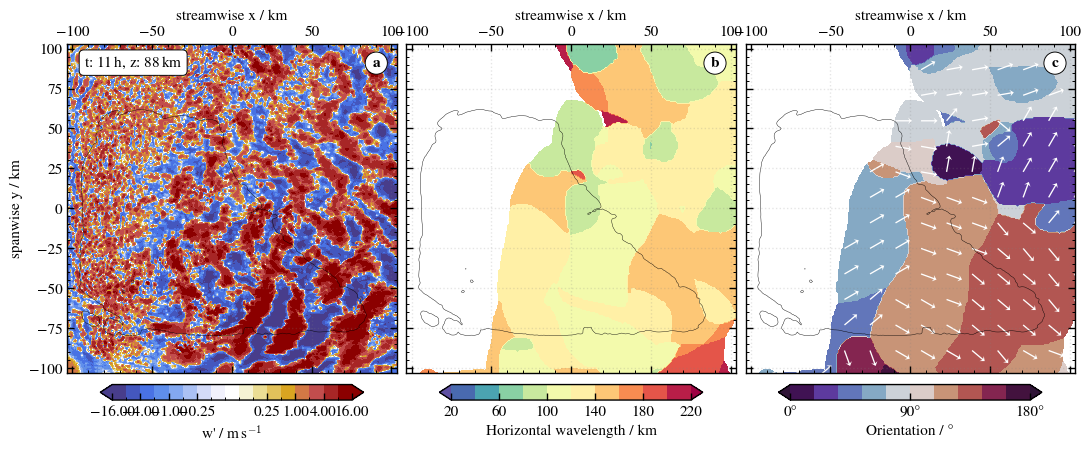

In [10]:
"""Figure wavelength and direction"""
xcr = dsxy['xcr'].values
ycr = dsxy['ycr'].values

xlim  = [ds.xcr.min().values+ds.dxabL/1000,ds.xcr.max().values-ds.dxabR/1000]
ylim  = [ds.ycr.min().values+ds.dyab/1000,ds.ycr.max().values-ds.dyab/1000]
# ylim  = [-300, 650]

surf_factor = 5
cmap   = cmaps.get_wave_cmap()
clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=16)
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

"""Figure stuff"""
gskw  = {'hspace':0.05, 'wspace':0.03, 'height_ratios': [8,1], 'width_ratios': [1,1,1]} 
fig, axes = plt.subplots(2,3, sharex=True, sharey=True, figsize=(13,5), gridspec_kw=gskw)

ax0 = axes[0,0]
ax1 = axes[0,1]
ax2 = axes[0,2]
for ax in axes[-1,0:3]:
    ax.set_axis_off()

ax0.set_aspect("equal")
ax1.set_aspect("equal")
ax2.set_aspect("equal")

contf_th = ax0.contourf(ds.xcr, ds.ycr, wavefield, cmap=cmap, norm=norm, levels=clev, extend='both')

levs_wavelengths = np.linspace(20,220,11)
lh = np.where(lh < 220, lh, np.nan)
contf_lh = ax1.contourf(xcr,ycr,lh,levels=levs_wavelengths,cmap="Spectral_r",extend="both")

levs_dir = np.linspace(0,np.pi,11)
ori = np.where(lh < 220, ori, np.nan)
contf_dir = ax2.contourf(xcr,ycr,ori,levels=levs_dir,cmap="twilight_shifted",extend="both")
# ax2.quiver(xcr[0::10,0::10],ycr[0::10,0::10],np.sin(ori[0::10,0::10]),np.cos(ori[0::10,0::10]),
#                  angles='xy', scale_units='xy', scale=0.3)

nn = 20
# Q = ax1.quiver(xcr[0,::nn],ds.ycr[::nn,0], efx[::nn, ::nn], efy[::nn,::nn], 
#                   angles='xy', color="k", width=0.008, scale=6, headwidth=3,headlength=2,headaxislength=2)
Q = ax2.quiver(xcr[0,::nn],ycr[::nn,0], np.sin(ori[0::nn,0::nn]), np.cos(ori[0::nn,0::nn]), 
                  angles='xy', color="white", width=0.004, scale=20, headwidth=5,headlength=3,headaxislength=2)

### - Topography - ###
if ds.itopo == 1:
    amp = dsxy.zcrtopo.max()
    amp = 1200
    topo_levels=np.linspace(20,surf_factor*amp,3)
else:
    if ds.amp < 0:
        topo_levels=np.linspace(surf_factor*ds.amp,-surf_factor*ds.amp,12)
    else: 
        topo_levels=np.linspace(-2*surf_factor*ds.amp,2*surf_factor*ds.amp,24)
ctopo = "k"
lwtopo = 0.3
ax0.contour(xcr, ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax1.contour(xcr, ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)
ax2.contour(xcr, ycr, surf_factor*dsxy.zcrtopo[t,:,:], colors=ctopo, levels=topo_levels, linewidths=lwtopo)

numstr = ['a','b','c']
for ip, ax in enumerate(axes[0,0:3]):
    ax.text(0.95, 0.93, numstr[ip], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(which='both', labeltop=True)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('streamwise x / km')
    ax.grid()
    
ax0.text(0.05, 0.93, "t: " + str(tstamp) + "$\,$h, z: " + str(int(dsxy.zpos)) + "$\,$km", transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# ax1.text(0.05, 0.93, "MF$_x$", transform=ax1.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
# ax2.text(0.05, 0.93, "MF$_y$", transform=ax2.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
ax0.set_ylabel('spanwise y / km')

cbar = fig.colorbar(contf_th, ax=axes[-1,0], orientation='horizontal', label=r"w' / m$\,$s$^{-1}$", ticks=clev_l, shrink=0.8, fraction=1,aspect=17) # anchor=(0,0)
cbar = fig.colorbar(contf_lh, ax=axes[-1,1], orientation='horizontal', label="Horizontal wavelength / km", shrink=0.8, fraction=1, aspect=17)
cbar = fig.colorbar(contf_dir, ax=axes[-1,2], orientation='horizontal', label="Orientation / °", shrink=0.8, fraction=1, aspect=17)
cbar.set_ticks(ticks=[0,np.pi/2,np.pi],labels=(['0°', '90°', '180°']))

fig_title = simulations[sim] + "_simple_wavelet" + str(int(dsxy.zpos)) + "_t" + str(tstamp) + "h.png"
imagefolder = "../data/figures"
os.makedirs(imagefolder, exist_ok=True)
fig.savefig(os.path.join(imagefolder,fig_title), facecolor='w', edgecolor='w',
            format='png', dpi=120, bbox_inches='tight')